# 🎓 Student Performance Prediction

**Author:** Shobhit Sharma
**Dataset:** Student Academic Performance Data

---


### Dataset Features:
- `Student_ID`: Unique identifier
- `Attendance (%)`: Class attendance percentage
- `Internal Test 1 & 2`: Mid-term scores (out of 40)
- `Assignment Score`: Assignment marks (out of 10)
- `Daily Study Hours`: Self-reported study time
- `Final Exam Marks`: **Target variable** (out of 100)

In [1]:
# =============================================================================
# STEP 0: ENVIRONMENT SETUP
# =============================================================================


import pandas as pd       
import numpy as np         
import matplotlib.pyplot as plt 
import seaborn as sns      
from scipy import stats    
import warnings
warnings.filterwarnings('ignore')  

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib             #

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


---

## 📊 PART 1: DATA LOADING & INITIAL EXPLORATION



In [2]:
# Load the dataset
df = pd.read_csv('Final_Marks_Data.csv')

# Basic dataset information
print("=" * 60)
print("📊 DATASET OVERVIEW")
print("=" * 60)
print(f"\n🔢 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n📋 Columns: {list(df.columns)}")


print("\n📌 First 5 Records:")
display(df.head())

# Data types and missing values
print("\n📊 Data Quality Check:")
info_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
    'Missing Values': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
display(info_df)

📊 DATASET OVERVIEW

🔢 Shape: 2000 rows × 7 columns

📋 Columns: ['Student_ID', 'Attendance (%)', 'Internal Test 1 (out of 40)', 'Internal Test 2 (out of 40)', 'Assignment Score (out of 10)', 'Daily Study Hours', 'Final Exam Marks (out of 100)']

📌 First 5 Records:


,Student_ID,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
0,S1000,84,30,36,7,3,72
1,S1001,91,24,38,6,3,56
2,S1002,73,29,26,7,3,56
3,S1003,80,36,35,7,3,74
4,S1004,84,31,37,8,3,66



📊 Data Quality Check:


,Data Type,Non-Null Count,Missing Values,Missing %
Student_ID,object,2000,0,0.0
Attendance (%),int64,2000,0,0.0
Internal Test 1 (out of 40),int64,2000,0,0.0
Internal Test 2 (out of 40),int64,2000,0,0.0
Assignment Score (out of 10),int64,2000,0,0.0
Daily Study Hours,int64,2000,0,0.0
Final Exam Marks (out of 100),int64,2000,0,0.0


In [3]:
# Statistical Summary
print("\n" + "=" * 60)
print("📈 DESCRIPTIVE STATISTICS")
print("=" * 60)

desc_stats = df.describe()
display(desc_stats.round(2))

# Key Insights
print("\n💡 KEY INSIGHTS:")
print(f"• Average Final Exam Score: {df['Final Exam Marks (out of 100)'].mean():.1f}")
print(f"• Highest Score: {df['Final Exam Marks (out of 100)'].max()}")
print(f"• Lowest Score: {df['Final Exam Marks (out of 100)'].min()}")
print(f"• Average Study Hours: {df['Daily Study Hours'].mean():.1f} hours/day")
print(f"• Average Attendance: {df['Attendance (%)'].mean():.1f}%")


📈 DESCRIPTIVE STATISTICS


,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,84.89,32.12,32.46,7.51,2.82,64.86
std,7.76,4.56,4.52,1.02,0.61,11.34
min,52.00,18.00,16.00,4.00,1.00,25.00
25%,80.00,29.00,29.00,7.00,2.00,58.00
50%,85.00,32.00,33.00,8.00,3.00,65.00
75%,90.00,35.00,36.00,8.00,3.00,73.00
max,100.00,40.00,40.00,10.00,5.00,100.00



💡 KEY INSIGHTS:
• Average Final Exam Score: 64.9
• Highest Score: 100
• Lowest Score: 25
• Average Study Hours: 2.8 hours/day
• Average Attendance: 84.9%


---

## 🔍 PART 2: EXPLORATORY DATA ANALYSIS (EDA)


### 2.1 Univariate Analysis (Single Variable)


📊 DISTRIBUTION ANALYSIS


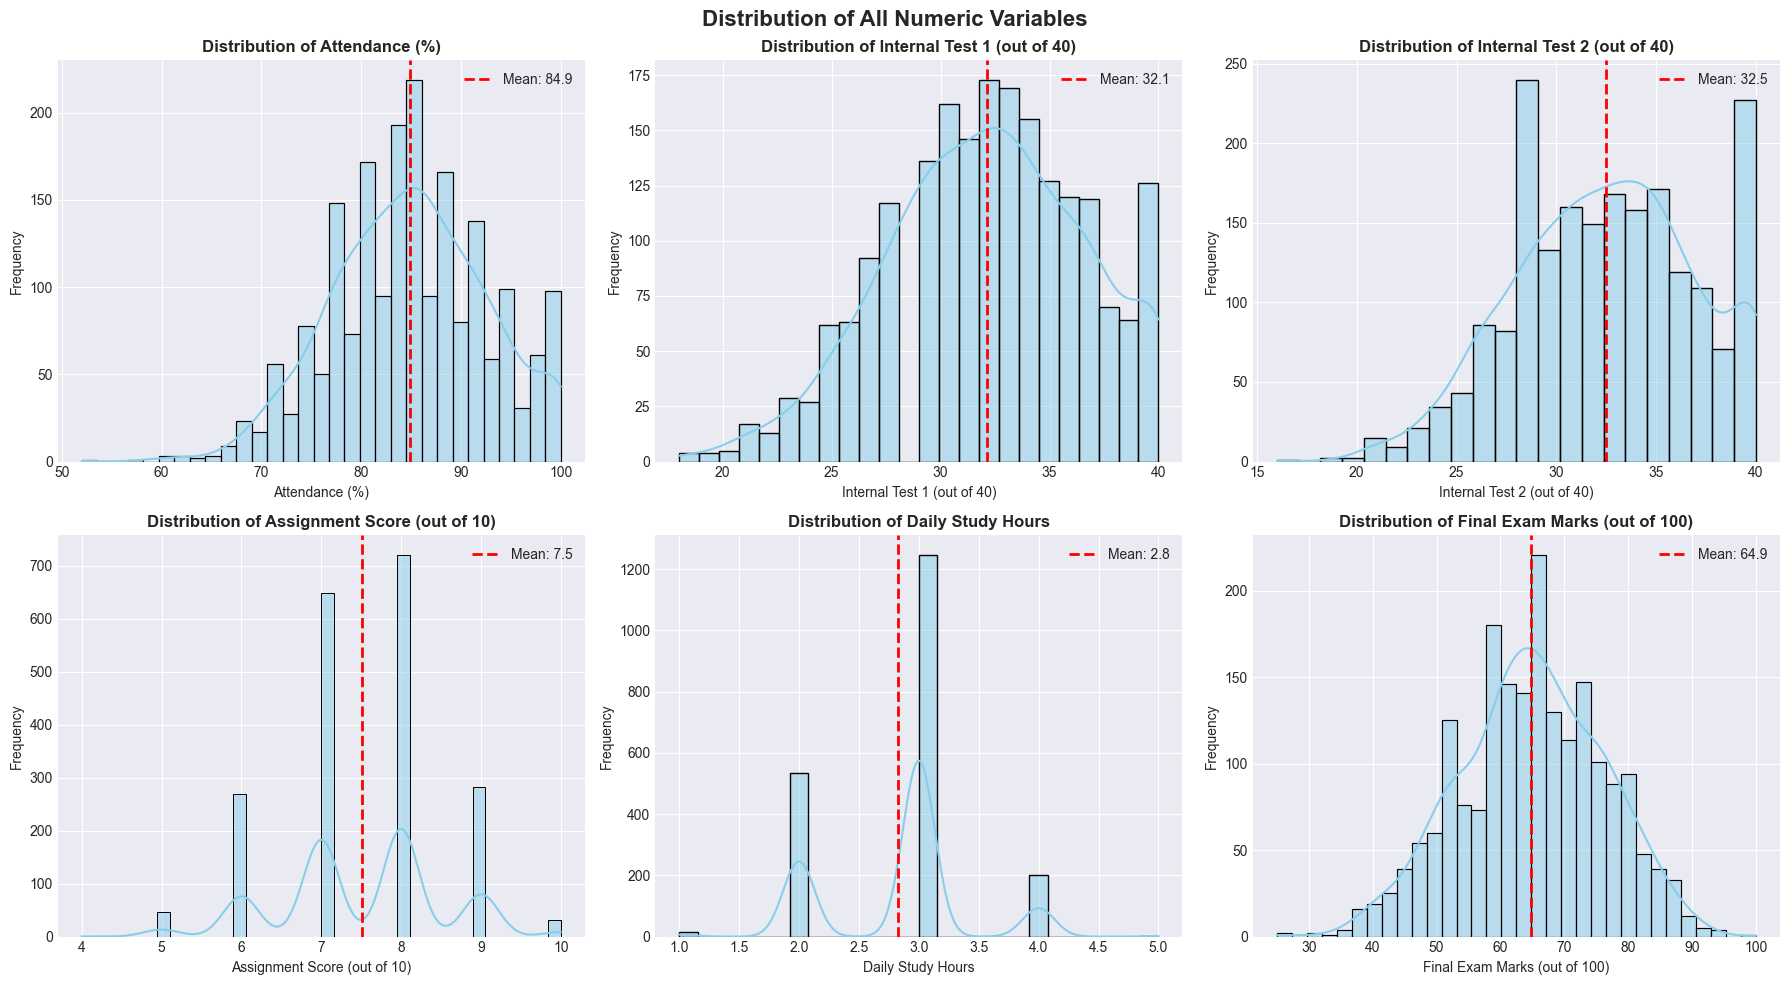

In [4]:
# Distribution Analysis
print("📊 DISTRIBUTION ANALYSIS")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribution of All Numeric Variables', fontsize=16, fontweight='bold')

numeric_cols = ['Attendance (%)', 'Internal Test 1 (out of 40)', 
                'Internal Test 2 (out of 40)', 'Assignment Score (out of 10)',
                'Daily Study Hours', 'Final Exam Marks (out of 100)']

for idx, col in enumerate(numeric_cols):
    row, col_idx = idx // 3, idx % 3
    ax = axes[row, col_idx]
    
    # Histogram with KDE (Kernel Density Estimate)
    sns.histplot(df[col], kde=True, ax=ax, color='skyblue', edgecolor='black')
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    
    # Add mean line
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {mean_val:.1f}')
    ax.legend()

plt.tight_layout()
plt.show()

In [5]:
# Statistical Tests for Normality
print("\n" + "=" * 60)
print("🔬 NORMALITY TESTS (Shapiro-Wilk Test)")
print("=" * 60)
print("H0: Data is normally distributed")
print("H1: Data is NOT normally distributed")
print("If p-value < 0.05, reject H0 (not normal)\n")

for col in numeric_cols:
    stat, p_value = stats.shapiro(df[col])
    status = "✅ Normal" if p_value > 0.05 else "❌ Not Normal"
    print(f"{col:35} | p-value: {p_value:.2e} | {status}")


🔬 NORMALITY TESTS (Shapiro-Wilk Test)
H0: Data is normally distributed
H1: Data is NOT normally distributed
If p-value < 0.05, reject H0 (not normal)

Attendance (%)                      | p-value: 3.94e-10 | ❌ Not Normal
Internal Test 1 (out of 40)         | p-value: 1.96e-15 | ❌ Not Normal
Internal Test 2 (out of 40)         | p-value: 7.16e-17 | ❌ Not Normal
Assignment Score (out of 10)        | p-value: 1.13e-31 | ❌ Not Normal
Daily Study Hours                   | p-value: 4.10e-46 | ❌ Not Normal
Final Exam Marks (out of 100)       | p-value: 2.19e-04 | ❌ Not Normal


### 2.2 Bivariate Analysis (Feature Relationships)

**Correlation Analysis** helps us understand how variables relate to each other:  
- **+1:** Perfect positive correlation (as one increases, other increases)
- **-1:** Perfect negative correlation (as one increases, other decreases)  
- **0:** No correlation


🔗 CORRELATION ANALYSIS


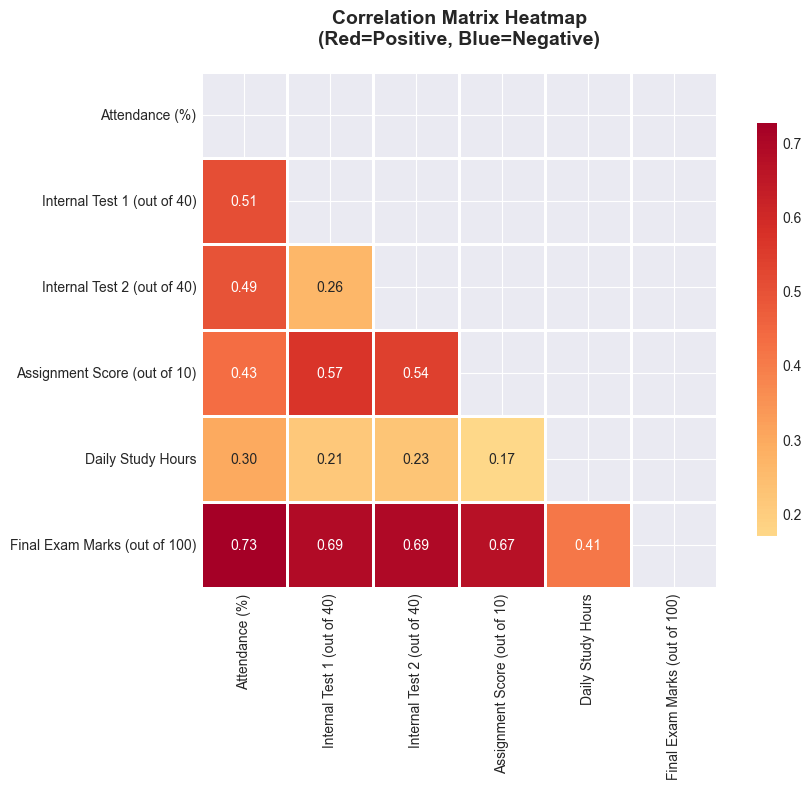


📈 Correlation with Final Exam Marks:
Final Exam Marks (out of 100)    1.000000
Attendance (%)                   0.725644
Internal Test 2 (out of 40)      0.691049
Internal Test 1 (out of 40)      0.689227
Assignment Score (out of 10)     0.669400
Daily Study Hours                0.412877
Name: Final Exam Marks (out of 100), dtype: float64


In [6]:
# Correlation Matrix
print("🔗 CORRELATION ANALYSIS")

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix Heatmap\n(Red=Positive, Blue=Negative)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Correlation with target
print("\n📈 Correlation with Final Exam Marks:")
target_corr = corr_matrix['Final Exam Marks (out of 100)'].sort_values(ascending=False)
print(target_corr)


📊 FEATURE RELATIONSHIPS:


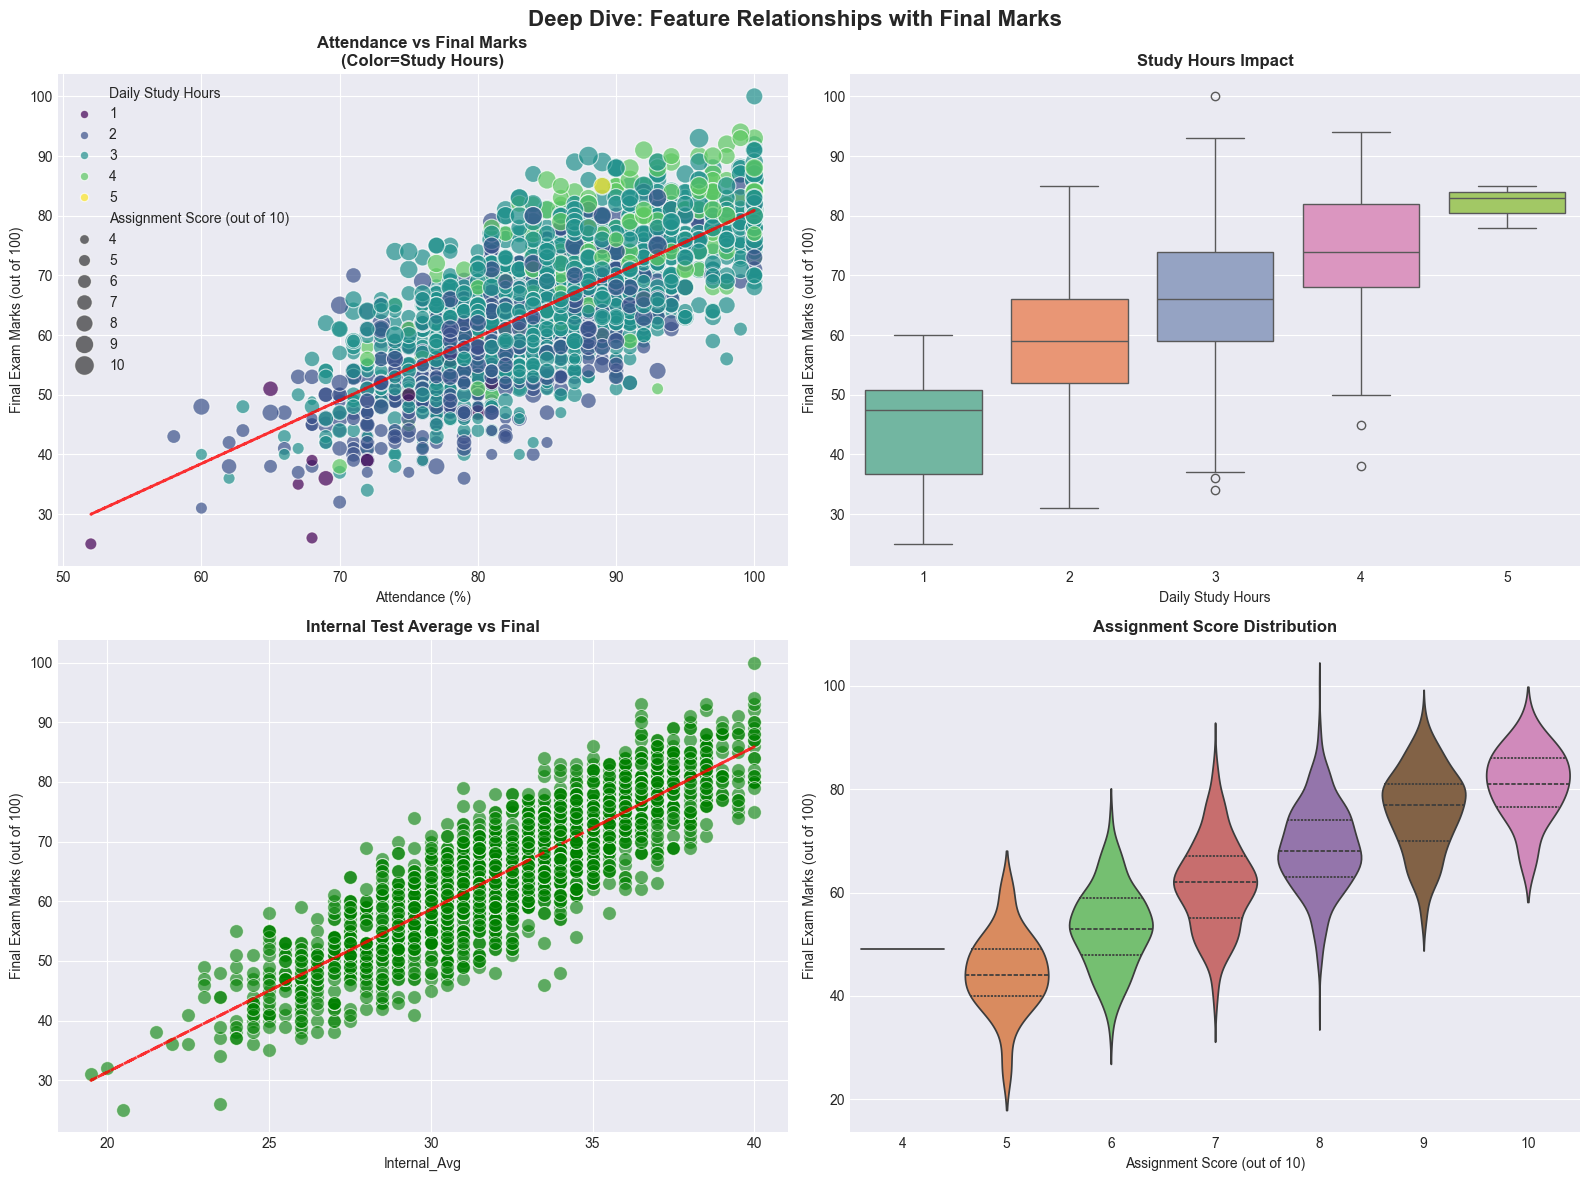

In [7]:
# Detailed Feature Relationships
print("\n📊 FEATURE RELATIONSHIPS:")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Deep Dive: Feature Relationships with Final Marks', fontsize=16, fontweight='bold')

# 1. Attendance vs Final Marks
ax1 = axes[0, 0]
sns.scatterplot(data=df, x='Attendance (%)', y='Final Exam Marks (out of 100)', 
                ax=ax1, hue='Daily Study Hours', size='Assignment Score (out of 10)',
                sizes=(50, 200), alpha=0.7, palette='viridis')
ax1.set_title('Attendance vs Final Marks\n(Color=Study Hours)', fontweight='bold')
z = np.polyfit(df['Attendance (%)'], df['Final Exam Marks (out of 100)'], 1)
p = np.poly1d(z)
ax1.plot(df['Attendance (%)'], p(df['Attendance (%)']), "r--", alpha=0.8, linewidth=2)

# 2. Study Hours vs Final Marks
ax2 = axes[0, 1]
sns.boxplot(data=df, x='Daily Study Hours', y='Final Exam Marks (out of 100)', 
            ax=ax2, palette='Set2')
ax2.set_title('Study Hours Impact', fontweight='bold')

# 3. Internal Test Average
df['Internal_Avg'] = (df['Internal Test 1 (out of 40)'] + df['Internal Test 2 (out of 40)']) / 2
ax3 = axes[1, 0]
sns.scatterplot(data=df, x='Internal_Avg', y='Final Exam Marks (out of 100)', 
                ax=ax3, color='green', alpha=0.6, s=100)
ax3.set_title('Internal Test Average vs Final', fontweight='bold')
z = np.polyfit(df['Internal_Avg'], df['Final Exam Marks (out of 100)'], 1)
p = np.poly1d(z)
ax3.plot(df['Internal_Avg'], p(df['Internal_Avg']), "r--", alpha=0.8, linewidth=2)

# 4. Assignment Score
ax4 = axes[1, 1]
sns.violinplot(data=df, x='Assignment Score (out of 10)', y='Final Exam Marks (out of 100)', 
               ax=ax4, palette='muted', inner='quartile')
ax4.set_title('Assignment Score Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

---

## 📊 PART 3: STATISTICAL SIGNIFICANCE TESTS

### Tests We'll Perform:
1. **T-Test:** Compare means between two groups
2. **ANOVA:** Compare means across multiple groups
3. **Chi-Square:** Test relationships between categorical variables

In [8]:
print("=" * 60)
print("📊 STATISTICAL SIGNIFICANCE TESTS")
print("=" * 60)

# 1. T-Test: High vs Low Attendance
median_attendance = df['Attendance (%)'].median()
high_att = df[df['Attendance (%)'] >= median_attendance]['Final Exam Marks (out of 100)']
low_att = df[df['Attendance (%)'] < median_attendance]['Final Exam Marks (out of 100)']

t_stat, p_val = stats.ttest_ind(high_att, low_att)

print(f"\n📊 T-TEST: High (≥{median_attendance}%) vs Low Attendance")
print(f"High Attendance Mean: {high_att.mean():.2f}")
print(f"Low Attendance Mean:  {low_att.mean():.2f}")
print(f"T-statistic: {t_stat:.4f}, p-value: {p_val:.2e}")
print(f"Result: {'✅ Significant' if p_val < 0.05 else '❌ Not Significant'} difference")

# 2. ANOVA: Study Hours effect
print(f"\n📊 ANOVA: Do Study Hours affect Final Marks?")
groups = [group['Final Exam Marks (out of 100)'].values 
          for name, group in df.groupby('Daily Study Hours')]
f_stat, p_val_anova = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}, p-value: {p_val_anova:.2e}")
print(f"Result: {'✅ Yes' if p_val_anova < 0.05 else '❌ No'} significant effect")

# 3. Chi-Square Test
print(f"\n📊 CHI-SQUARE TEST: Study Hours vs Performance Categories")
df['Grade_Category'] = pd.cut(df['Final Exam Marks (out of 100)'], 
                              bins=[0, 50, 70, 85, 100], 
                              labels=['Fail', 'Pass', 'Good', 'Excellent'])
contingency = pd.crosstab(df['Daily Study Hours'], df['Grade_Category'])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-square: {chi2:.4f}, p-value: {p_chi:.2e}")
print("\nContingency Table:")
display(contingency)

📊 STATISTICAL SIGNIFICANCE TESTS

📊 T-TEST: High (≥85.0%) vs Low Attendance
High Attendance Mean: 71.16
Low Attendance Mean:  57.94
T-statistic: 32.0035, p-value: 8.60e-182
Result: ✅ Significant difference

📊 ANOVA: Do Study Hours affect Final Marks?
F-statistic: 104.7536, p-value: 4.48e-81
Result: ✅ Yes significant effect

📊 CHI-SQUARE TEST: Study Hours vs Performance Categories
Chi-square: 342.9563, p-value: 4.29e-66

Contingency Table:


Grade_Category,Fail,Pass,Good,Excellent
Daily Study Hours,,,,
1,10,4,0,0
2,120,339,74,0
3,88,744,383,33
4,4,63,113,22
5,0,0,3,0


---

## 🤖 PART 4: MACHINE LEARNING MODELING

### The Machine Learning Workflow:

```
Raw Data → Preprocessing → Feature Engineering → Model Training → Evaluation → Deployment
```


In [9]:
print("=" * 60)
print("⚙️ DATA PREPARATION")
print("=" * 60)

# Feature Engineering: Create new meaningful feature
df['Internal_Avg'] = (df['Internal Test 1 (out of 40)'] + df['Internal Test 2 (out of 40)']) / 2

# Select features
feature_columns = ['Attendance (%)', 'Internal Test 1 (out of 40)', 
                   'Internal Test 2 (out of 40)', 'Assignment Score (out of 10)',
                   'Daily Study Hours', 'Internal_Avg']

X = df[feature_columns]  # Features (inputs)
y = df['Final Exam Marks (out of 100)']  # Target (output)

print(f"✅ Features: {feature_columns}")
print(f"✅ Target: Final Exam Marks")
print(f"✅ Shape: X={X.shape}, y={y.shape}")

# Train-Test Split (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n📊 Split:")
print(f"Training: {len(X_train)} samples ({len(X_train)/len(X)*100:.0f}%)")
print(f"Testing:  {len(X_test)} samples ({len(X_test)/len(X)*100:.0f}%)")

# Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Features standardized (mean=0, std=1)")

⚙️ DATA PREPARATION
✅ Features: ['Attendance (%)', 'Internal Test 1 (out of 40)', 'Internal Test 2 (out of 40)', 'Assignment Score (out of 10)', 'Daily Study Hours', 'Internal_Avg']
✅ Target: Final Exam Marks
✅ Shape: X=(2000, 6), y=(2000,)

📊 Split:
Training: 1600 samples (80%)
Testing:  400 samples (20%)

✅ Features standardized (mean=0, std=1)


### 4.1 Model 1: Linear Regression


In [10]:
print("\n" + "=" * 60)
print("🤖 MODEL 1: LINEAR REGRESSION")
print("=" * 60)

# Initialize and train
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluation Metrics
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print(f"\n📊 Linear Regression Results:")
print(f"RMSE: {lr_rmse:.2f} (avg error in marks)")
print(f"MAE:  {lr_mae:.2f} (mean absolute error)")
print(f"R²:   {lr_r2:.4f} (explained variance)")
print(f"\n💡 R² = {lr_r2:.1%} of variance explained")

# Feature Coefficients
coef_df = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"\n📈 Feature Importance (Coefficients):")
display(coef_df)


🤖 MODEL 1: LINEAR REGRESSION

📊 Linear Regression Results:
RMSE: 4.62 (avg error in marks)
MAE:  3.67 (mean absolute error)
R²:   0.8297 (explained variance)

💡 R² = 83.0% of variance explained

📈 Feature Importance (Coefficients):


,Feature,Coefficient
0,Attendance (%),3.062174
5,Internal_Avg,2.858627
1,Internal Test 1 (out of 40),2.292736
2,Internal Test 2 (out of 40),2.225816
4,Daily Study Hours,1.770510
3,Assignment Score (out of 10),1.475696


### 4.2 Model 2: Random Forest Regression



🌲 MODEL 2: RANDOM FOREST REGRESSOR

📊 Random Forest Results:
RMSE: 4.93
MAE:  3.91
R²:   0.8058

💡 R² = 80.6% of variance explained

🌟 Feature Importance:


,Feature,Importance
5,Internal_Avg,0.806895
0,Attendance (%),0.102598
4,Daily Study Hours,0.027217
3,Assignment Score (out of 10),0.022415
2,Internal Test 2 (out of 40),0.020853
1,Internal Test 1 (out of 40),0.020022


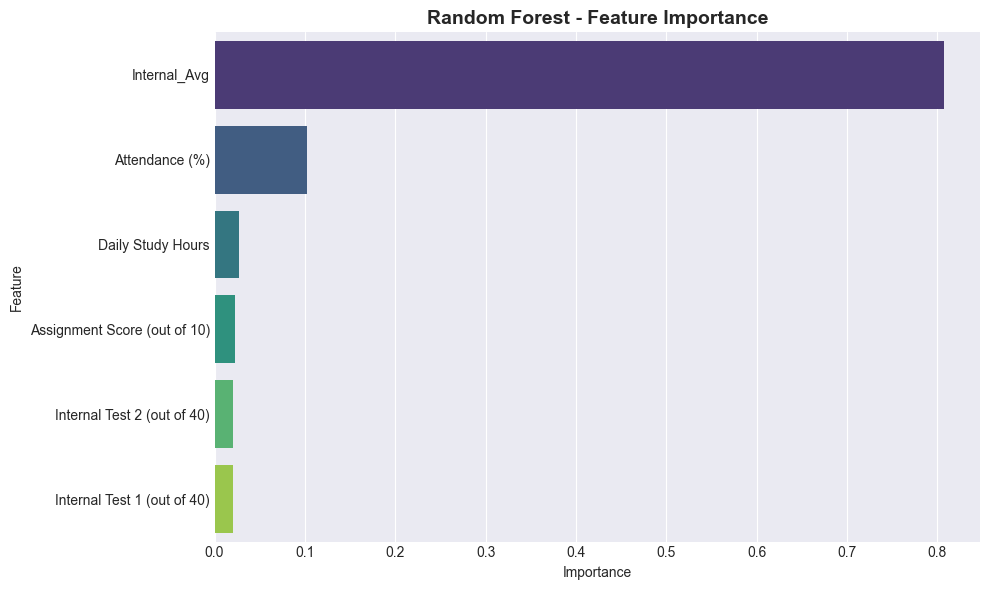

In [11]:
print("\n" + "=" * 60)
print("🌲 MODEL 2: RANDOM FOREST REGRESSOR")
print("=" * 60)

# Initialize with hyperparameters
rf_model = RandomForestRegressor(
    n_estimators=100,      # Number of trees
    max_depth=10,          # Prevent overfitting
    min_samples_split=5,   # Minimum samples to split
    random_state=42,
    n_jobs=-1              # Use all CPU cores
)

# Train (no scaling needed for tree-based models)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print(f"\n📊 Random Forest Results:")
print(f"RMSE: {rf_rmse:.2f}")
print(f"MAE:  {rf_mae:.2f}")
print(f"R²:   {rf_r2:.4f}")
print(f"\n💡 R² = {rf_r2:.1%} of variance explained")

# Feature Importance
importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n🌟 Feature Importance:")
display(importance_df)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, y='Feature', x='Importance', palette='viridis')
plt.title('Random Forest - Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 Model Comparison & Visualization




⚔️ MODEL COMPARISON


,Metric,Linear Regression,Random Forest
0,RMSE ↓,4.6179,4.9323
1,MAE ↓,3.6750,3.9080
2,R² Score ↑,0.8297,0.8058


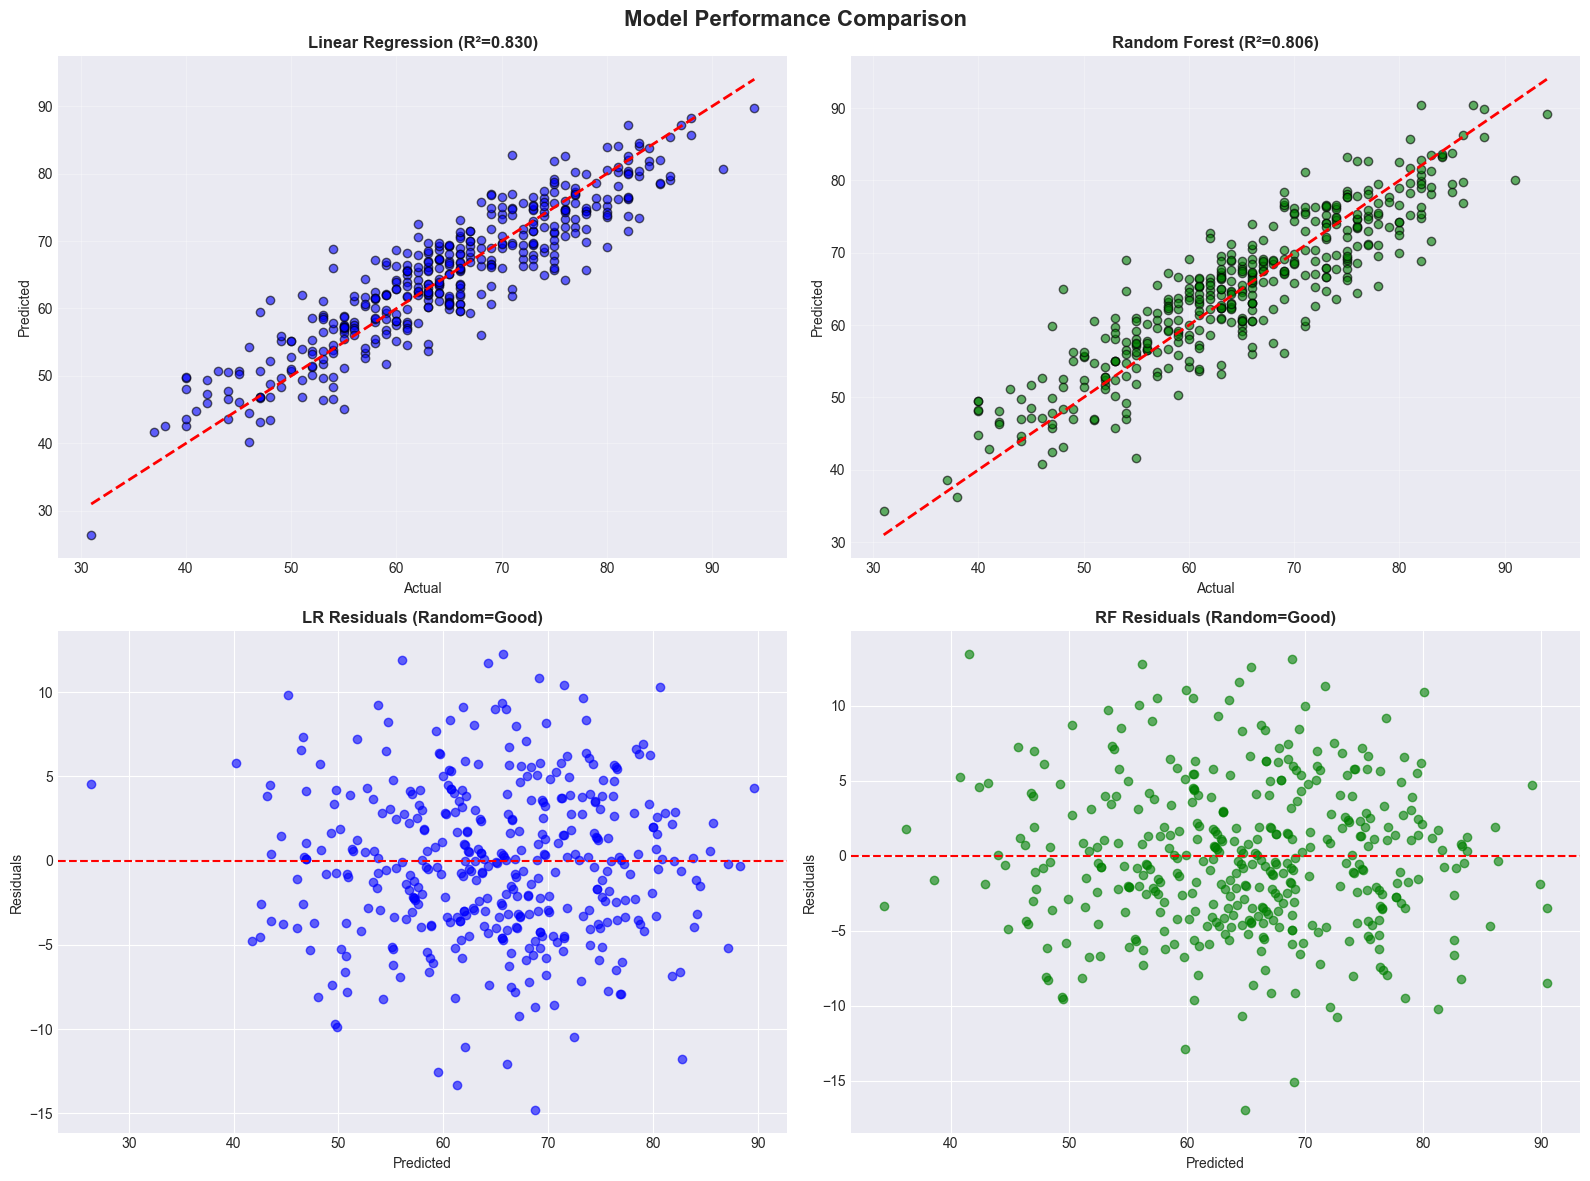

In [12]:
print("\n" + "=" * 60)
print("⚔️ MODEL COMPARISON")
print("=" * 60)

comparison = pd.DataFrame({
    'Metric': ['RMSE ↓', 'MAE ↓', 'R² Score ↑'],
    'Linear Regression': [lr_rmse, lr_mae, lr_r2],
    'Random Forest': [rf_rmse, rf_mae, rf_r2]
})
display(comparison.round(4))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Actual vs Predicted - Linear Regression
axes[0, 0].scatter(y_test, y_pred_lr, alpha=0.6, color='blue', edgecolors='k')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual')
axes[0, 0].set_ylabel('Predicted')
axes[0, 0].set_title(f'Linear Regression (R²={lr_r2:.3f})', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Actual vs Predicted - Random Forest
axes[0, 1].scatter(y_test, y_pred_rf, alpha=0.6, color='green', edgecolors='k')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual')
axes[0, 1].set_ylabel('Predicted')
axes[0, 1].set_title(f'Random Forest (R²={rf_r2:.3f})', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Residuals - Linear Regression
residuals_lr = y_test - y_pred_lr
axes[1, 0].scatter(y_pred_lr, residuals_lr, alpha=0.6, color='blue')
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('LR Residuals (Random=Good)', fontweight='bold')

# 4. Residuals - Random Forest
residuals_rf = y_test - y_pred_rf
axes[1, 1].scatter(y_pred_rf, residuals_rf, alpha=0.6, color='green')
axes[1, 1].axhline(y=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('RF Residuals (Random=Good)', fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 🚀 PART 5: MODEL DEPLOYMENT


In [13]:
print("=" * 60)
print("💾 MODEL DEPLOYMENT")
print("=" * 60)

# Select best model
best_model = rf_model if rf_r2 > lr_r2 else lr_model
best_r2 = max(rf_r2, lr_r2)
model_name = 'Random Forest' if rf_r2 > lr_r2 else 'Linear Regression'

print(f"\n✅ Best Model: {model_name} (R² = {best_r2:.4f})")

# Save model and scaler
model_file = 'student_performance_model.pkl'
scaler_file = 'scaler.pkl'

joblib.dump(best_model, model_file)
joblib.dump(scaler, scaler_file)

print(f"\n💾 Saved: {model_file}")
print(f"💾 Saved: {scaler_file}")

# Create prediction function
def predict_performance(attendance, test1, test2, assignment, study_hours):
    """
    Predict final exam marks for a student.
    
    Parameters:
    -----------
    attendance : float - Attendance % (0-100)
    test1, test2 : float - Internal test marks (0-40)
    assignment : float - Assignment score (0-10)
    study_hours : int - Daily study hours
    
    Returns:
    --------
    predicted_marks : float - Predicted final exam marks (0-100)
    """
    # Calculate internal average
    internal_avg = (test1 + test2) / 2
    
    # Create input array
    input_data = np.array([[attendance, test1, test2, assignment, study_hours, internal_avg]])
    
    # Predict
    if model_name == 'Linear Regression':
        input_scaled = scaler.transform(input_data)
        prediction = best_model.predict(input_scaled)[0]
    else:
        prediction = best_model.predict(input_data)[0]
    
    # Clip to valid range
    return max(0, min(100, round(prediction, 2)))

print("\n✅ Prediction function created!")

💾 MODEL DEPLOYMENT

✅ Best Model: Linear Regression (R² = 0.8297)

💾 Saved: student_performance_model.pkl
💾 Saved: scaler.pkl

✅ Prediction function created!


In [14]:
# Test with example students
print("\n" + "=" * 60)
print("🎯 DEPLOYMENT TESTING")
print("=" * 60)

test_students = [
    {"name": "Excellent Student", "attendance": 95, "test1": 38, "test2": 39, "assignment": 9, "study_hours": 4},
    {"name": "Average Student", "attendance": 80, "test1": 30, "test2": 32, "assignment": 7, "study_hours": 3},
    {"name": "At-Risk Student", "attendance": 65, "test1": 22, "test2": 24, "assignment": 5, "study_hours": 1}
]

for student in test_students:
    pred = predict_performance(
        student["attendance"],
        student["test1"],
        student["test2"],
        student["assignment"],
        student["study_hours"]
    )
    
    # Grade calculation
    if pred >= 85: grade = "A (Excellent)"
    elif pred >= 70: grade = "B (Good)"
    elif pred >= 50: grade = "C (Pass)"
    else: grade = "F (Fail)"
    
    print(f"\n📊 {student['name']}:")
    print(f"   Attendance: {student['attendance']}%, Study: {student['study_hours']}h/day")
    print(f"   🎓 Predicted: {pred}/100 → Grade: {grade}")

print("\n" + "=" * 60)
print("✅ DEPLOYMENT READY!")
print("=" * 60)


🎯 DEPLOYMENT TESTING

📊 Excellent Student:
   Attendance: 95%, Study: 4h/day
   🎓 Predicted: 85.43/100 → Grade: A (Excellent)

📊 Average Student:
   Attendance: 80%, Study: 3h/day
   🎓 Predicted: 60.44/100 → Grade: C (Pass)

📊 At-Risk Student:
   Attendance: 65%, Study: 1h/day
   🎓 Predicted: 31.7/100 → Grade: F (Fail)

✅ DEPLOYMENT READY!
